<a href="https://colab.research.google.com/github/mobarakol/tutorial_notebooks/blob/main/Gradient_Descent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch    0 | Loss = 1.816951
Epoch  200 | Loss = 1.637795
Epoch  400 | Loss = 1.495616
Epoch  600 | Loss = 1.387583
Epoch  800 | Loss = 1.306253
Epoch 1000 | Loss = 1.244458
Epoch 1200 | Loss = 1.196702
Epoch 1400 | Loss = 1.159083
Epoch 1600 | Loss = 1.128890
Epoch 1800 | Loss = 1.104236
Epoch 2000 | Loss = 1.083790
Epoch 2200 | Loss = 1.066598
Epoch 2400 | Loss = 1.051965
Epoch 2600 | Loss = 1.039374
Epoch 2800 | Loss = 1.028435
Epoch 3000 | Loss = 1.018849
Epoch 3200 | Loss = 1.010385
Epoch 3400 | Loss = 1.002860
Epoch 3600 | Loss = 0.996127
Epoch 3800 | Loss = 0.990069

Final weights: [0.33935724 0.37892606]
Final bias: [0.10306666]


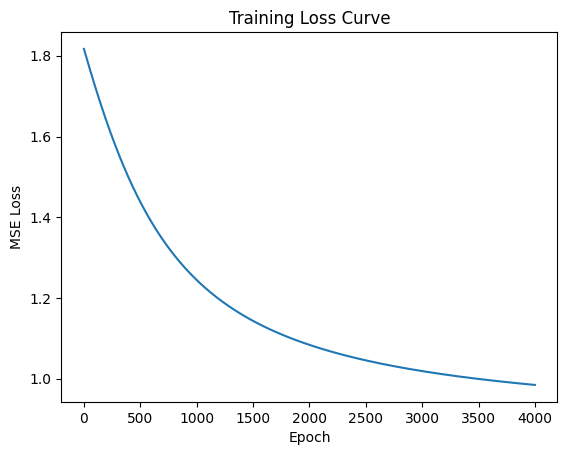


Test input: [[1. 2.]]
Predicted output: [[0.76857388]]


In [8]:
import numpy as np
import matplotlib.pyplot as plt

# =========================================================
# Data: 2 inputs (x1, x2) and 1 output (y)
# =========================================================
X = np.array([
    [1.0, 2.0],
    [2.0, 3.0],
    [3.0, 4.0],
    [4.0, 5.0]
])  # (N, 2)

y = np.array([
    [1.0],
    [1.5],
    [2.0],
    [2.5]
])  # (N, 1)

N = X.shape[0]

# =========================================================
# Parameters
# =========================================================
np.random.seed(42)
W = np.random.randn(2, 1) * 0.1
b = np.zeros((1,))

learning_rate = 0.0001
epochs = 4000

# =========================================================
# Activation (sigmoid) + derivative
# =========================================================
def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-z))

def sigmoid_grad(z):
    s = sigmoid(z)
    return s * (1.0 - s)

# =========================================================
# Train with Gradient Descent + store loss
# =========================================================
loss_history = []

for epoch in range(epochs):
    # Forward
    z = X @ W + b              # (N, 1)
    y_pred = sigmoid(z)        # (N, 1)

    # Loss (MSE)
    loss = np.mean((y_pred - y) ** 2)
    loss_history.append(loss)

    # Backward
    dL_dy = 2.0 * (y_pred - y) / N       # (N, 1)
    dL_dz = dL_dy * sigmoid_grad(z)       # (N, 1)

    dL_dW = X.T @ dL_dz                   # (2, 1)
    dL_db = np.sum(dL_dz, axis=0)         # (1,)

    # Update
    W -= learning_rate * dL_dW
    b -= learning_rate * dL_db

    if epoch % 200 == 0:
        print(f"Epoch {epoch:4d} | Loss = {loss:.6f}")

# =========================================================
# Print final parameters
# =========================================================
print("\nFinal weights:", W.ravel())
print("Final bias:", b)

# =========================================================
# Plot loss curve
# =========================================================
plt.figure()
plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("Training Loss Curve")
plt.show()

# =========================================================
# Test prediction
# =========================================================
x_test = np.array([[1.0, 2.0]])
y_test_pred = sigmoid(x_test @ W + b)
print("\nTest input:", x_test)
print("Predicted output:", y_test_pred)
